# The goal of this notebook is to apply Kernel Density Estimation within the lifecycle of each outbreak-producing cyclone

In [1]:
## import packages
import pandas as pd
import os
from pathlib import Path
import re
import warnings
#warnings.filterwarnings('ignore')
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.colors as col
from matplotlib.gridspec import GridSpec
import matplotlib.dates as mdates
import cmocean
import cartopy.feature as cfeature
import cartopy.crs as ccrs
import numpy as np
import seaborn as sns
import xarray as xr

from sklearn.neighbors import KernelDensity
from scipy.ndimage import label
from scipy import stats
from shapely.geometry import Point, Polygon

import networkx as nx
import itertools

In [2]:
reports_tagged = pd.read_csv('data/reports_tagged_initial.csv', low_memory=False)

In [3]:
reports_tagged

,EVENT_ID,time_hour,report_lat,report_lon,EVENT_TYPE,BEGIN_DT_UTC,BEGIN_YEARMONTH,BEGIN_DAY,BEGIN_TIME,END_YEARMONTH,...,dist_km,rlon,rlat,track_start,track_end,time_min_msl,min_msl,n_steps,lifecycle_frac,hours_from_min_msl
0,10351815,1995-12-17 16:00:00+00:00,29.4700,-95.0500,Tornado,1995-12-17 15:45:00+00:00,199512,17,945,199512,...,565.361833,4.2000,3.4700,1995-12-16 21:00:00+00:00,1995-12-26 13:00:00+00:00,1995-12-21 18:00:00+00:00,970.2875,212.0,0.081897,-98.0
1,10328563,1995-12-17 20:00:00+00:00,31.2200,-92.1700,Tornado,1995-12-17 19:40:00+00:00,199512,17,1340,199512,...,942.067203,6.8300,5.9700,1995-12-16 21:00:00+00:00,1995-12-26 13:00:00+00:00,1995-12-21 18:00:00+00:00,970.2875,212.0,0.099138,-94.0
2,10327292,1995-12-17 20:00:00+00:00,30.5500,-91.5500,Tornado,1995-12-17 20:12:00+00:00,199512,17,1412,199512,...,939.379509,7.4500,5.3000,1995-12-16 21:00:00+00:00,1995-12-26 13:00:00+00:00,1995-12-21 18:00:00+00:00,970.2875,212.0,0.099138,-94.0
3,10327420,1995-12-18 19:00:00+00:00,30.6000,-90.2300,Tornado,1995-12-18 19:15:00+00:00,199512,18,1315,199512,...,386.951821,2.2700,-2.9000,1995-12-16 21:00:00+00:00,1995-12-26 13:00:00+00:00,1995-12-21 18:00:00+00:00,970.2875,212.0,0.198276,-71.0
4,10354458,1995-12-17 14:00:00+00:00,28.8700,-96.2200,Tornado,1995-12-17 14:10:00+00:00,199512,17,810,199512,...,404.309660,3.5300,1.8700,1995-12-16 21:00:00+00:00,1995-12-26 13:00:00+00:00,1995-12-21 18:00:00+00:00,970.2875,212.0,0.073276,-100.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
83964,1290825,2025-03-31 03:00:00+00:00,38.1571,-83.3841,Thunderstorm Wind,2025-03-31 03:20:00+00:00,202503,30,2320,202503,...,709.138149,-0.8841,-6.3429,2025-03-26 22:00:00+00:00,2025-03-31 23:00:00+00:00,2025-03-31 20:00:00+00:00,992.6212,114.0,0.834711,-17.0
83965,1290828,2025-03-31 04:00:00+00:00,37.1871,-83.7779,Thunderstorm Wind,2025-03-31 04:20:00+00:00,202503,31,20,202503,...,847.740553,-1.2779,-7.5629,2025-03-26 22:00:00+00:00,2025-03-31 23:00:00+00:00,2025-03-31 20:00:00+00:00,992.6212,114.0,0.842975,-16.0
83966,1290851,2025-03-31 05:00:00+00:00,37.3389,-82.5863,Thunderstorm Wind,2025-03-31 05:19:00+00:00,202503,31,119,202503,...,892.881198,-1.8363,-7.9111,2025-03-26 22:00:00+00:00,2025-03-31 23:00:00+00:00,2025-03-31 20:00:00+00:00,992.6212,114.0,0.851240,-15.0
83967,1249986,2025-03-27 07:00:00+00:00,26.0711,-97.1590,Thunderstorm Wind,2025-03-27 07:00:00+00:00,202503,27,200,202503,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
## Read in only reports that are associated with an ETC
df = reports_tagged.dropna(subset=['track_id']).copy()
df['track_id'] = df['track_id'].astype(int)
df['time_hour'] = pd.to_datetime(df['time_hour'], utc=True)

In [5]:
print(f"{len(df)} tagged reports across {df['track_id'].nunique()} tracks")

67189 tagged reports across 891 tracks


## Kernel Density Estimation core functions:

In [6]:
### Core Clustering Function:
def kde_cluster_track(g: pd.DataFrame,
                      bandwidth: float=1.0,
                      pdf_thresh: float = 0.001,
                      dx: float=0.25,
                      pad: float=2.0,
                      win_hours: int=24,
                      step_hours: int=1,
                      min_reports: int=1,
                      min_core_reports: int=2) -> pd.Series:
    """
    Identify outbreak "cores within a report-producing cyclone via sliding-window 2-D KDE.
    
    Follows Shafer and Doswell (2011): Gaussian KDE of report (lon, lat), binarize at a PDF
    threshold, label connected 'islands'. Adds a temporal dimension by sliding a 24h window in 1h 
    time steps; islands that share any report (across overlapping windows) are merged into a single 
    core via connected components. 

    Parameters:
    -----------
    g: reports for a SINGLE track_id (needs 'time_hour',' report_lon','report_lat').
    bandwidth: Gaussian LDE bandwidth in DEGREES (=sigma = h). S&D used 1.0.
    pdf_thresh: density threshold in (degree)^-2 for an island. S&D used 0.001.
    dx: meshgrid spacing (degrees). Affects island resolution only. 
    pad: degrees of padding around the report bounding box so contours can close.
    win_hours, step_hours: sliding-window length and step.
    min_reports: a window is only analyzed if it hold strictly more than this. (will not be relevant for
    when we use all 30 years of reports))

    Returns
    -------
    pd.Series of integer core ids (0..k-1) indexed like g; -1=never assigned.
    """

    g = g.sort_values('time_hour')
    lon = g['report_lon'].to_numpy()
    lat = g['report_lat'].to_numpy()
    times = g['time_hour']
    idx = g.index.to_numpy()
    n = len(g)

    win = pd.Timedelta(hours=win_hours)
    step = pd.Timedelta(hours=step_hours)
    t_end = times.max()

    ## Graph over reports (nodes = positional indices 0..n-1)

    G = nx.Graph()
    G.add_nodes_from(range(n))
    assigned = np.zeros(n, dtype=bool)

    start = times.min()
    while start <= t_end:
        in_win = ((times >= start) & (times < start + win)).to_numpy() ## create boolean mask
        sub = np.where(in_win)[0]  
        start = start + step
        if len(sub) <= min_reports:
            continue

        xs, ys = lon[sub], lat[sub]

        ## Meshgrid over the padded bounding box of this window's reports.
        gx = np.arange(xs.min() - pad, xs.max() + pad + dx, dx)
        gy = np.arange(ys.min() - pad, ys.max() + pad + dx, dx)
        GX, GY = np.meshgrid(gx, gy)

        # Fit + evaluate KDE; np.exp(score_samples) is the PDF in (deg)^-2.
        kde = KernelDensity(bandwidth=bandwidth, kernel='gaussian')
        kde.fit(np.column_stack([xs,ys]))

        dens = np.exp(kde.score_samples(np.column_stack([GX.ravel(),GY.ravel()])))
        dens = dens.reshape(GX.shape)

        # Binarize - label islands.
        labels, nlab = label(dens > pdf_thresh)
        if nlab == 0:
            continue

        ## Assign each report to the island of its nearest grid cell
        ix = np.clip(np.round((xs - gx[0]) / dx).astype(int), 0, len(gx)-1)
        iy = np.clip(np.round((ys - gy[0]) / dx).astype(int), 0, len(gy)-1)
        lab_per_report = labels[iy, ix]

        ## Within each island, chain members together
        for L in range(1, nlab+1):
            members = sub[lab_per_report == L]
            assigned[members] = True
            for a in range(len(members)-1):
                G.add_edge(members[a], members[a + 1])

    ## Connected components - core ids (only reports that landed in some island)
    core = np.full(n, -1, dtype=int)
    cid = 0
    for comp in nx.connected_components(G):
        comp = [c for c in comp if assigned[c]]
        if len(comp) < min_core_reports:
            continue
        if not comp:
            continue
        for c in comp:
            core[c] = cid
        cid += 1

    return pd.Series(core, index=idx, name='core_local')
        

In [32]:
## Assign a globally-unique core_id to every report
core_local = pd.Series(-1,index=df.index, dtype=int)

for tid, g in df.groupby('track_id'):
    core_local.loc[g.index] = kde_cluster_track(g, 
                                                win_hours=12, 
                                                bandwidth=1,
                                                pdf_thresh=0.001)

df['core_local'] = core_local
df['core_id'] = np.where(df['core_local'] >= 0,
                         df['track_id'].astype(str) + '_' + df['core_local'].astype(str),
                         np.nan)
print(f'{df['core_id'].notna().sum()} / {len(df)} reports assigned to a core')
print(f'{df['core_id'].nunique()} cores across {df['track_id'].nunique()} tracks')

66774 / 67189 reports assigned to a core
1109 cores across 891 tracks


In [33]:
## Split each core wherever its reports have a temporal gap longer than 'gap hours',
## operates on the output of kde_cluster_track. A continuous outbreak (no quiet period) 
## is preserved as one core; two episodes separated by a quiet stretch are split, encoding 
## the diffferent mesoscale driver criterion as much as possible

def split_cores_on_gap(df, gap_hours):
    """
    Break each existing core at temporal gaps longer than 'gap hours'.
    """

    gap = pd.Timedelta(hours=gap_hours)
    new_core = pd.Series(np.nan, index = df.index, dtype=object)

    for cid, g in df.dropna(subset=['core_id']).groupby('core_id'):
        g = g.sort_values('time_hour')
        t = g['time_hour']

        ## Gap to the PREVIOUS report within this core. First report has no 
        ## predecesor - treat as 0 so it always starts segment 0
        dt = t.diff()

        ## A new segment begins at each report whose gap to the prior one
        ## exceeds the threshold. cumsum turns those breakpoints into 0,1,2...
        seg = (dt > gap).cumsum()

        n_seg = seg.nunique()
        if n_seg == 1:
            # no qualifying gap: core survives intact, keep original id.
            new_core.loc[g.index] = cid
        else:
            ## suffix each segment so new cores remain globally unique
            for s, sub_idx in seg.groupby(seg):
                members = seg.index[seg == s]
                new_core.loc[members] = f"{cid}g{s}"

    ## unassign any post-gap-split cores with only one report. 
    core_sizes = new_core.value_counts()
    new_core.loc[new_core.map(core_sizes).eq(1)] = np.nan

    return new_core

In [34]:
df['core_id'] = split_cores_on_gap(df, gap_hours=3)
print(f'{df['core_id'].notna().sum()} / {len(df)} reports assigned to a core')
print(f'{df['core_id'].nunique()} cores across {df['track_id'].nunique()} tracks')

66568 / 67189 reports assigned to a core
1461 cores across 891 tracks


In [35]:
core_summary = (
    df.dropna(subset=['core_id'])
    .groupby(['track_id', 'core_id'])
    .agg(n_reports=('EVENT_ID','size'),
         n_tornado=('EVENT_TYPE', lambda s: (s == 'Tornado').sum()),
         n_hail=('EVENT_TYPE', lambda s: (s == 'Hail').sum()),
         n_wind=('EVENT_TYPE', lambda s: (s == 'Thunderstorm Wind').sum()),
         t_start=('time_hour','min'),
         t_end=('time_hour','max'),
         lat_min=('report_lat','min'), lax_max=('report_lat','max'),
         lon_min=('report_lon','min'), lon_max=('report_lon','max'))
    .reset_index()
)

core_summary['duration_h'] = (
    (core_summary['t_end'] - core_summary['t_start']).dt.total_seconds() / 3600
)
core_summary.sort_values('n_reports', ascending=False).head(15)

,track_id,core_id,n_reports,n_tornado,n_hail,n_wind,t_start,t_end,lat_min,lax_max,lon_min,lon_max,duration_h
1439,6102,6102_2,1061,146,355,560,2025-03-14 14:00:00+00:00,2025-03-16 02:00:00+00:00,30.1300,43.63000,-102.27990,-80.97000,36.0
513,2168,2168_1g0,1060,124,797,139,2006-03-11 21:00:00+00:00,2006-03-13 15:00:00+00:00,33.1500,42.68333,-98.66667,-81.21667,42.0
1008,4387,4387_1g2,987,78,299,610,2017-02-28 21:00:00+00:00,2017-03-01 18:00:00+00:00,34.6700,42.49000,-95.93000,-77.09490,21.0
791,3372,3372_1,933,108,573,252,2012-03-02 09:00:00+00:00,2012-03-03 20:00:00+00:00,30.4578,41.13000,-94.11000,-79.55000,35.0
1458,6117,6117_4g1,821,63,207,551,2025-03-30 13:00:00+00:00,2025-03-31 23:00:00+00:00,30.7600,43.87990,-98.95000,-75.77000,34.0
1010,4391,4391_1,781,76,205,500,2017-03-06 20:00:00+00:00,2017-03-07 11:00:00+00:00,34.9009,46.43000,-97.43000,-87.00730,15.0
837,3558,3558_0,780,75,44,661,2013-01-29 04:00:00+00:00,2013-01-31 09:00:00+00:00,29.7364,42.43000,-99.40000,-74.70630,53.0
1243,5421,5421_1,778,167,28,583,2021-12-15 18:00:00+00:00,2021-12-16 05:00:00+00:00,37.2000,45.50000,-100.16320,-89.11000,11.0
1143,5018,5018_0,686,63,1,622,2020-01-11 08:00:00+00:00,2020-01-12 08:00:00+00:00,29.4500,40.10600,-94.32000,-77.10000,24.0
590,2546,2546_2g1,592,120,138,334,2008-02-05 19:00:00+00:00,2008-02-06 13:00:00+00:00,30.0500,39.85000,-96.12000,-80.63590,18.0


#### Detrending Process

In [ ]:
def add_density_ratio(core_summary: pd.DataFrame,
                      df: pd.DataFrame,
                      bandwidth: float = 1.0,
                      pdf_thresh: float = 0.001,
                      dx: float = 0.25,
                      pad: float = 2.0) -> pd.DataFrame:
    """
    Attach grid_points and density_ratio to core_summary.

    Parameters mirror the engine / plotting defaults so the contour counted
    here is the SAME footprint we draw in plot_track_cores.

    core_summary : must have columns ['core_id', 'n_reports'].
    df           : the per-report frame with ['core_id','report_lon','report_lat'].
    dx           : grid spacing in degrees. MUST match the value used elsewhere
                   so density_ratio is comparable across all cores.
    """
    grid_points = {}

    # group reports by their final core_id
    for cid, gc in df.dropna(subset=['core_id']).groupby('core_id'):
        xs = gc['report_lon'].to_numpy()
        ys = gc['report_lat'].to_numpy()

        # A single-point core can't form a 2-D KDE contour; assign 1 grid
        # point so density_ratio is defined (and large -> these are exactly
        # the sparse singletons the n_reports bar will also catch).
        if len(xs) < 2:
            grid_points[cid] = 1
            continue

        gx = np.arange(xs.min() - pad, xs.max() + pad + dx, dx)
        gy = np.arange(ys.min() - pad, ys.max() + pad + dx, dx)
        GX, GY = np.meshgrid(gx, gy)

        kde = KernelDensity(bandwidth=bandwidth, kernel='gaussian')
        kde.fit(np.column_stack([xs, ys]))
        dens = np.exp(
            kde.score_samples(np.column_stack([GX.ravel(), GY.ravel()]))
        ).reshape(GX.shape)

        # zero the border so an open contour at the padded edge doesn't
        # inflate the count (mirrors the border-zeroing in plot_track_cores)
        dens[[0, -1], :] = 0
        dens[:, [0, -1]] = 0

        n_cells = int((dens > pdf_thresh).sum())
        # guard: if nothing clears the threshold (very sparse core), use 1
        grid_points[cid] = max(n_cells, 1)

    out = core_summary.copy()
    out['grid_points'] = out['core_id'].map(grid_points)
    out['density_ratio'] = out['n_reports'] / out['grid_points']
    return out

In [37]:
def _log_linear_fit(years: np.ndarray, annual_means: np.ndarray):
    """
    Fit log(annual_mean) = a*year + b by OLS; return a callable that gives
    the fitted (detrended) mean for any year, plus the (a, b) coefficients.

    log space because the reporting inflation is ~exponential (S&D Figs 3-4).
    """
    y = np.asarray(years, dtype=float)
    m = np.asarray(annual_means, dtype=float)

    # guard against zero/negative means (a year with all-empty metric)
    good = m > 0
    if good.sum() < 2:
        # not enough points to fit a trend; fall back to a flat line at the
        # overall mean (degenerate, but keeps the pipeline running)
        flat = np.nanmean(m[good]) if good.any() else 0.0
        return (lambda yr: np.full_like(np.asarray(yr, float), flat)), (0.0, np.log(flat) if flat > 0 else 0.0)

    a, b = np.polyfit(y[good], np.log(m[good]), 1)
    fitted = lambda yr: np.exp(a * np.asarray(yr, dtype=float) + b)
    return fitted, (a, b)


In [38]:
def prune_detrended(core_summary: pd.DataFrame,
                    year_col: str = 'year',
                    return_fits: bool = False):
    """
    Apply S&D detrended pruning to core_summary.

    Requires columns: ['n_reports', 'density_ratio', year_col].
    If year_col is absent, it is derived from 't_start'.

    Adds columns:
      thr_reports        fitted (detrended) annual-mean n_reports for the core's year
      thr_density_ratio  fitted (detrended) annual-mean density_ratio for the core's year
      kept               True if n_reports >= thr_reports AND
                              density_ratio >= thr_density_ratio

    Returns the augmented core_summary (and the two fit objects if
    return_fits=True), so you can plot the regression curves S&D-style.
    """
    cs = core_summary.copy()

    if year_col not in cs.columns:
        cs[year_col] = pd.to_datetime(cs['t_start'], utc=True).dt.year

    # --- annual means across that year's cores ---
    annual = (cs.groupby(year_col)
                .agg(mean_reports=('n_reports', 'mean'),
                     mean_density=('density_ratio', 'mean'))
                .reset_index())

    yrs = annual[year_col].to_numpy()

    fit_reports, coef_r = _log_linear_fit(yrs, annual['mean_reports'].to_numpy())
    fit_density, coef_d = _log_linear_fit(yrs, annual['mean_density'].to_numpy())

    # --- evaluate the fitted curve at each core's year = its threshold ---
    cs['thr_reports'] = fit_reports(cs[year_col].to_numpy())
    cs['thr_density_ratio'] = fit_density(cs[year_col].to_numpy())

    # --- S&D keep rule: must clear BOTH bars ---
    cs['kept'] = (
        (cs['n_reports'] >= cs['thr_reports']) 
        &                                                  ## commenting out to use just reports threshold
        (cs['density_ratio'] >= cs['thr_density_ratio'])
    )

    if return_fits:
        fits = {
            'fit_reports': fit_reports, 'coef_reports': coef_r,
            'fit_density': fit_density, 'coef_density': coef_d,
            'annual': annual,
        }
        return cs, fits
    return cs


In [39]:
core_summary = add_density_ratio(core_summary, df,
                                 bandwidth=1, pdf_thresh=0.001,
                                 dx=0.25, pad=2.0)

In [40]:
## DJFM season year: making sure December belongs to the FOLLOWING year's winter
ts = pd.to_datetime(core_summary['t_start'], utc=True)
core_summary['season_year'] = np.where(ts.dt.month == 12,
                                       ts.dt.year + 1, ts.dt.year)

In [41]:
core_summary, fits = prune_detrended(core_summary,
                                     year_col='season_year',
                                     return_fits=True)

In [42]:
## propagate the per-core 'kept' flag down to the report-level df
kept_map = core_summary.set_index('core_id')['kept']
df['core_kept'] = df['core_id'].map(kept_map)

## check reports in pruned out cores:
n_dropped = (df['core_kept'] == False).sum()
n_kept    = (df['core_kept'] == True).sum()
n_nocore  = df['core_kept'].isna().sum()
print(f"reports in KEPT cores:    {n_kept}")
print(f"reports in DROPPED cores: {n_dropped}")
print(f"reports with no core:     {n_nocore}")

reports in KEPT cores:    55078
reports in DROPPED cores: 11490
reports with no core:     621


In [43]:
n_kept = core_summary['kept'].sum()
print(f"detrended pruning: kept {n_kept} / {len(core_summary)} cores "
      f"({100*n_kept/len(core_summary):.1f}%)")
print(f"  log-linear slope, reports : {fits['coef_reports'][0]:+.4f} /yr")
print(f"  log-linear slope, density : {fits['coef_density'][0]:+.4f} /yr")

detrended pruning: kept 332 / 1461 cores (22.7%)
  log-linear slope, reports : +0.0124 /yr
  log-linear slope, density : +0.0082 /yr


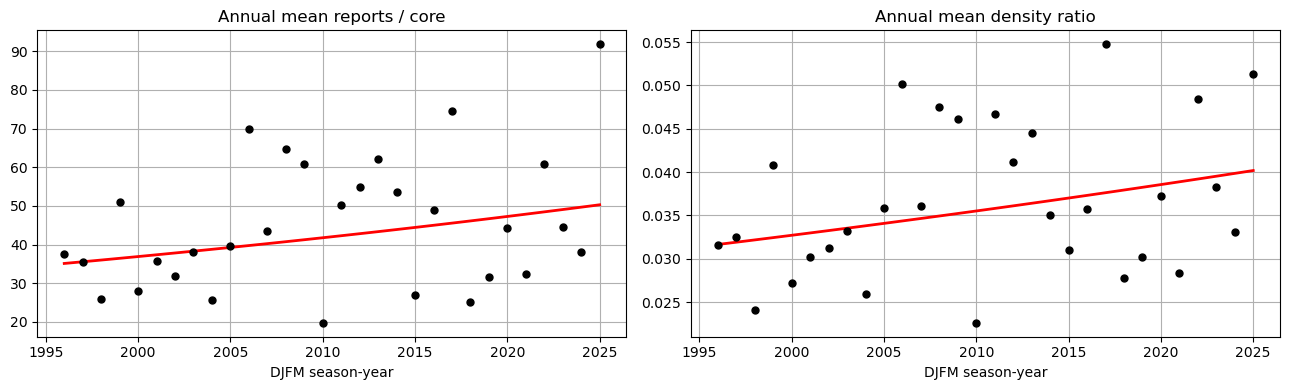

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
annual = fits['annual']
yy = np.linspace(annual['season_year'].min(), annual['season_year'].max(), 100)

for ax, col, fitkey, ttl in [
    (axes[0], 'mean_reports', 'fit_reports', 'Annual mean reports / core'),
    (axes[1], 'mean_density', 'fit_density', 'Annual mean density ratio'),
]:
    ax.scatter(annual['season_year'], annual[col], s=25, color='k', zorder=3)
    ax.plot(yy, fits[fitkey](yy), 'r-', lw=2, zorder=2)
    ax.set_title(ttl); ax.set_xlabel('DJFM season-year')
    ax.grid(True)
plt.tight_layout() 
plt.show()

In [20]:
cs = core_summary
fail_reports = (cs['n_reports'] < cs['thr_reports']).sum()
fail_density = (cs['density_ratio'] < cs['thr_density_ratio']).sum()
fail_both    = ((cs['n_reports'] < cs['thr_reports']) &
                (cs['density_ratio'] < cs['thr_density_ratio'])).sum()
print(f"fail reports bar only: {fail_reports - fail_both}")
print(f"fail density bar only: {fail_density - fail_both}")
print(f"fail both:             {fail_both}")
print(f"kept (clear both):     {cs['kept'].sum()}")

# Of the cores that failed ONLY the density bar, how big are they?
only_density = cs[(cs['density_ratio'] < cs['thr_density_ratio']) &
                  (cs['n_reports'] >= cs['thr_reports'])]
print(f"\ncores failing ONLY density bar: {len(only_density)}")
print(only_density['n_reports'].describe())

# Of the cores that failed ONLY the density bar, how big are they?
only_reports = cs[(cs['n_reports'] < cs['thr_reports']) &
                  (cs['density_ratio'] >= cs['thr_density_ratio'])]
print(f"\ncores failing ONLY report bar: {len(only_reports)}")
print(only_reports['n_reports'].describe())

fail reports bar only: 67
fail density bar only: 4
fail both:             1135
kept (clear both):     347

cores failing ONLY density bar: 4
count     4.000000
mean     47.000000
std       5.887841
min      41.000000
25%      44.000000
50%      46.000000
75%      49.000000
max      55.000000
Name: n_reports, dtype: float64

cores failing ONLY report bar: 67
count    67.000000
mean     31.582090
std       6.681384
min      17.000000
25%      28.000000
50%      32.000000
75%      36.000000
max      47.000000
Name: n_reports, dtype: float64


In [21]:
print(core_summary[['n_reports','grid_points','density_ratio']].describe())
print("\nzero/one grid_point cores:", (core_summary['grid_points'] <= 1).sum())

         n_reports  grid_points  density_ratio
count  1553.000000  1553.000000    1553.000000
mean     42.602061   498.229234       0.056651
std      98.972023   226.937904       0.098391
min       2.000000   225.000000       0.003831
25%       3.000000   316.000000       0.009823
50%       8.000000   438.000000       0.020349
75%      34.000000   623.000000       0.057851
max    1055.000000  1345.000000       1.146739

zero/one grid_point cores: 0


In [22]:
print(f"{len(only_density)} cores fail the density threshold")
only_density[['core_id', 'track_id','n_reports', 'density_ratio', 'thr_density_ratio', 'kept']]


4 cores fail the density threshold


,core_id,track_id,n_reports,density_ratio,thr_density_ratio,kept
743,2953_0,2953,45,0.043647,0.053871,False
856,3384_1g1,3384,41,0.039767,0.055014,False
980,4134_0g0,4134,55,0.055388,0.057374,False
1407,5687_0g1,5687,47,0.053348,0.061749,False


#### time series of clusters and ETCs per year:

In [23]:
## Time series of clusters and ETCs per year
def build_year_timeseries(core_summary, year_col='season_year'):
    """
    Per season-year: number of kept cores, total cores, and number of
    distinct outbreak-producing ETCs (tracks that have >=1 kept core).

    Requires a boolean 'kept' column and 'track_id'.
    """
    cs = core_summary
    kept = cs[cs['kept']]

    ts = (cs.groupby(year_col)
            .agg(total_cores=('core_id', 'nunique'),
                 total_etcs=('track_id', 'nunique'))
            .join(
                kept.groupby(year_col)
                    .agg(kept_cores=('core_id', 'nunique'),
                         outbreak_etcs=('track_id', 'nunique'))
            )
            .fillna(0)
            .astype(int)
            .reset_index())
    ts['kept_frac'] = (ts['kept_cores'] / ts['total_cores']).round(3)
    return ts


def plot_year_timeseries(ts, year_col='season_year'):
    import matplotlib.pyplot as plt
    fig, ax = plt.subplots(figsize=(11, 5))
    x = ts[year_col]

    ax.bar(x - 0.2, ts['kept_cores'], width=0.4,
           label='kept cores', color='steelblue')
    ax.bar(x + 0.2, ts['outbreak_etcs'], width=0.4,
           label='outbreak-producing ETCs', color='darkorange')
    ax.set_xlabel('DJFM season-year')
    ax.set_ylabel('count')
    ax.set_title('Kept outbreak cores and outbreak-producing ETCs per season')
    ax.legend(loc='upper left')
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    return fig, ax

In [24]:
year_ts = build_year_timeseries(core_summary, year_col='season_year')
print(year_ts.to_string(index=False))

 season_year  total_cores  total_etcs  kept_cores  outbreak_etcs  kept_frac
        1996           52          26          11              8      0.212
        1997           56          33          15             14      0.268
        1998           86          30          14             12      0.163
        1999           43          25          14             11      0.326
        2000           58          27          13             10      0.224
        2001           36          21           8              7      0.222
        2002           40          21           7              6      0.175
        2003           34          20           9              6      0.265
        2004           30          18           3              3      0.100
        2005           46          21          14             12      0.304
        2006           47          20          15             12      0.319
        2007           42          20          10              8      0.238
        2008

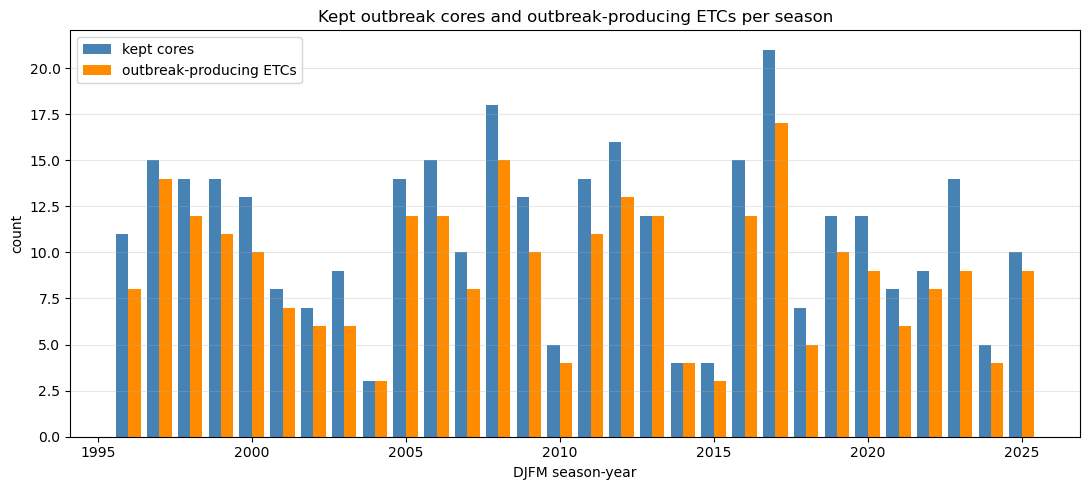

In [26]:
fig, ax = plot_year_timeseries(year_ts)

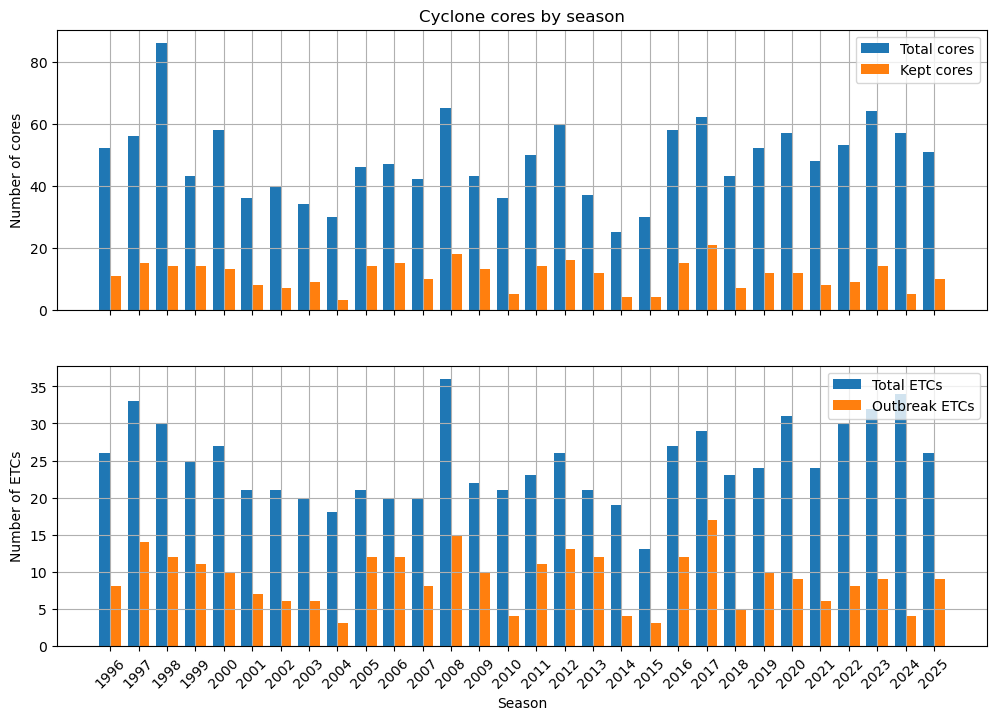

In [27]:
x = np.arange(len(year_ts))
width = 0.38

fig, (ax1, ax2) = plt.subplots(
    2, 1,
    figsize=(12, 8),
    sharex=True,
    #constrained_layout=True
)

# --------------------
# Cores
# --------------------
ax1.bar(x - width/2, year_ts["total_cores"], width,
        label="Total cores")
ax1.bar(x + width/2, year_ts["kept_cores"], width,
        label="Kept cores")

ax1.set_ylabel("Number of cores")
ax1.set_title("Cyclone cores by season")
ax1.legend()
ax1.grid(True)

# --------------------
# ETCs
# --------------------
ax2.bar(x - width/2, year_ts["total_etcs"], width,
        label="Total ETCs")
ax2.bar(x + width/2, year_ts["outbreak_etcs"], width,
        label="Outbreak ETCs")

ax2.set_ylabel("Number of ETCs")
ax2.set_xlabel("Season")
ax2.legend(loc='upper right')
ax2.grid(True)

ax2.set_xticks(x)
ax2.set_xticklabels(year_ts["season_year"], rotation=45)

plt.show()

### Plotting ETC, Storm Reports, and KDE cores

In [26]:
#df = pd.read_csv('data/reports_tagged_final.csv', low_memory=False)
#df['time_hour'] = pd.to_datetime(df['time_hour'], utc=True)


tracks_h = pd.read_csv('data/nodes_with_reports_final.csv', parse_dates=['time_hour'])
tracks_h['time_hour'] = pd.to_datetime(tracks_h['time_hour'], utc=True)

In [45]:
def plot_track_cores(track_id, df, tracks_h, bandwidth=1.0, pdf_thresh=0.001, dx=0.25, pad=2.0, savepath=False):
    """Map a track's reports in type colors, with a KDE contour per core
    and the cyclone track (line + 'L' every 6 h) overlaid."""

    g = df[df['track_id'] == track_id].sort_values('time_hour')
    track = tracks_h[tracks_h['track_id'] == track_id].sort_values('time_hour')

    
    track_6h = track[track['time_hour'].dt.hour % 6 == 0]

    lon_min, lon_max, lat_min, lat_max = -122.0, -72.5, 21.5, 50.0

    track_6h = track_6h[
    (track_6h['lon'] >= lon_min) & (track_6h['lon'] <= lon_max) &
    (track_6h['lat'] >= lat_min) & (track_6h['lat'] <= lat_max)
    ]

    et = g['EVENT_TYPE'].str.upper().fillna('OTHER')
    is_wind = et.str.contains('THUNDERSTORM WIND')
    is_hail = et.str.contains('HAIL')
    is_tor  = et.str.contains('TORNADO')

    keep = g['core_kept'] == True ## reports in a kept core
    drop = ~keep ## non-kept cores and no-core reports

    proj = ccrs.LambertConformal(central_longitude=-95)
    fig = plt.figure(figsize=(11, 7))
    ax = plt.axes(projection=proj)
    ax.add_feature(cfeature.STATES, lw=0.4, edgecolor='grey')
    ax.add_feature(cfeature.COASTLINE, lw=0.6)
    ax.add_feature(cfeature.BORDERS, lw=0.6)

    # --- Cyclone track line + 'L' markers every 6 h ---
    ax.plot(track['lon'], track['lat'],
            color='black', linewidth=1.2, alpha=0.6,
            transform=ccrs.PlateCarree(), zorder=3)
    for _, row in track_6h.iterrows():
        ax.text(row['lon'], row['lat'], 'L',
                fontsize=15, fontweight='bold', color='red',
                ha='center', va='center',
                transform=ccrs.PlateCarree(), zorder=5)

    # --- KDE contour per KEPT core only, one color each ---
    kept_cores = g.loc[keep, 'core_id'].dropna().unique()
    palette = plt.cm.tab10(np.linspace(0, 1, max(len(kept_cores), 1)))
    for color, cid in zip(palette, kept_cores):
        gc = g[g['core_id'] == cid]
        xs, ys = gc['report_lon'].to_numpy(), gc['report_lat'].to_numpy()
        if len(xs) < 2:
            continue
        gx = np.arange(xs.min() - pad, xs.max() + pad + dx, dx)
        gy = np.arange(ys.min() - pad, ys.max() + pad + dx, dx)
        GX, GY = np.meshgrid(gx, gy)
        kde = KernelDensity(bandwidth=bandwidth, kernel='gaussian').fit(np.column_stack([xs, ys]))
        dens = np.exp(kde.score_samples(np.column_stack([GX.ravel(), GY.ravel()]))).reshape(GX.shape)
        dens[[0, -1], :] = 0
        dens[:, [0, -1]] = 0
        ax.contour(GX, GY, dens, levels=[pdf_thresh], colors=[color], linewidths=1.2,
                   transform=ccrs.PlateCarree(), zorder=4)
        
    # --- Pruned-core reports in grey (drawn first, underneath) ---
    ax.scatter(g.loc[drop, 'report_lon'], g.loc[drop, 'report_lat'],
               s=15, c='grey', alpha=0.5, marker='o',
               edgecolor='black', linewidth=0.2,
               transform=ccrs.PlateCarree(), zorder=4, label='Pruned core')

    # --- Kept-core reports in type colors ---
    ax.scatter(g.loc[is_wind & keep, 'report_lon'], g.loc[is_wind & keep, 'report_lat'],
               s=15, c='blue', alpha=0.7, marker='o',
               edgecolor='black', linewidth=0.2,
               transform=ccrs.PlateCarree(), zorder=5, label='T-Storm Wind')
    ax.scatter(g.loc[is_hail & keep, 'report_lon'], g.loc[is_hail & keep, 'report_lat'],
               s=15, c='lime', alpha=0.7, marker='o',
               edgecolor='black', linewidth=0.2,
               transform=ccrs.PlateCarree(), zorder=6, label='Hail')
    ax.scatter(g.loc[is_tor & keep, 'report_lon'], g.loc[is_tor & keep, 'report_lat'],
               s=40, c='red', alpha=0.7, marker='v',
               edgecolor='black', linewidth=0.5,
               transform=ccrs.PlateCarree(), zorder=7, label='Tornado')

    ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())
    ax.legend(loc='lower left', fontsize=8, framealpha=0.9)
    ax.set_title(f"track {track_id}: {g.loc[keep, 'core_id'].nunique()} kept core(s), "
                 f"{g['time_hour'].min():%Y-%m-%d %H}Z – {g['time_hour'].max():%m-%d %H}Z")
    if savepath:
        fig.savefig(f'etc_kde_{track_id}_3.png', dpi=200, bbox_inches='tight')
    plt.show()


In [46]:
## This is the same but eliminates the KDE contours

# def plot_track_cores(track_id, df, tracks_h, bandwidth=1.0, pdf_thresh=0.001, dx=0.25, pad=2.0, savepath=False):
#     """Map a track's reports in type colors, with a KDE contour per core
#     and the cyclone track (line + 'L' every 6 h) overlaid."""

#     g = df[df['track_id'] == track_id].sort_values('time_hour')
#     track = tracks_h[tracks_h['track_id'] == track_id].sort_values('time_hour')

    
#     track_6h = track[track['time_hour'].dt.hour % 6 == 0]

#     lon_min, lon_max, lat_min, lat_max = -122.0, -72.5, 21.5, 50.0

#     track_6h = track_6h[
#     (track_6h['lon'] >= lon_min) & (track_6h['lon'] <= lon_max) &
#     (track_6h['lat'] >= lat_min) & (track_6h['lat'] <= lat_max)
#     ]

#     et = g['EVENT_TYPE'].str.upper().fillna('OTHER')
#     is_wind = et.str.contains('THUNDERSTORM WIND')
#     is_hail = et.str.contains('HAIL')
#     is_tor  = et.str.contains('TORNADO')

#     keep = g['core_kept'] == True ## reports in a kept core
#     drop = ~keep ## non-kept cores and no-core reports

#     proj = ccrs.LambertConformal(central_longitude=-95)
#     fig = plt.figure(figsize=(11, 7))
#     ax = plt.axes(projection=proj)
#     ax.add_feature(cfeature.STATES, lw=0.4, edgecolor='grey')
#     ax.add_feature(cfeature.COASTLINE, lw=0.6)
#     ax.add_feature(cfeature.BORDERS, lw=0.6)

#     # --- Cyclone track line + 'L' markers every 6 h ---
#     ax.plot(track['lon'], track['lat'],
#             color='black', linewidth=1.2, alpha=0.6,
#             transform=ccrs.PlateCarree(), zorder=3)
#     for _, row in track_6h.iterrows():
#         ax.text(row['lon'], row['lat'], 'L',
#                 fontsize=15, fontweight='bold', color='red',
#                 ha='center', va='center',
#                 transform=ccrs.PlateCarree(), zorder=5)

#     # --- Kept-core reports in type colors ---
#     ax.scatter(g.loc[is_wind, 'report_lon'], g.loc[is_wind, 'report_lat'],
#                s=15, c='blue', alpha=0.7, marker='o',
#                edgecolor='black', linewidth=0.2,
#                transform=ccrs.PlateCarree(), zorder=5, label='T-Storm Wind')
#     ax.scatter(g.loc[is_hail, 'report_lon'], g.loc[is_hail, 'report_lat'],
#                s=15, c='lime', alpha=0.7, marker='o',
#                edgecolor='black', linewidth=0.2,
#                transform=ccrs.PlateCarree(), zorder=6, label='Hail')
#     ax.scatter(g.loc[is_tor, 'report_lon'], g.loc[is_tor, 'report_lat'],
#                s=40, c='red', alpha=0.7, marker='v',
#                edgecolor='black', linewidth=0.5,
#                transform=ccrs.PlateCarree(), zorder=7, label='Tornado')

#     ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())
#     ax.legend(loc='lower left', fontsize=8, framealpha=0.9)
#     ax.set_title(f"track {track_id}:  "
#                  f"{g['time_hour'].min():%Y-%m-%d %H}Z – {g['time_hour'].max():%m-%d %H}Z")
#     if savepath:
#         fig.savefig('etc_kde.png', dpi=200, bbox_inches='tight')
#     plt.show()


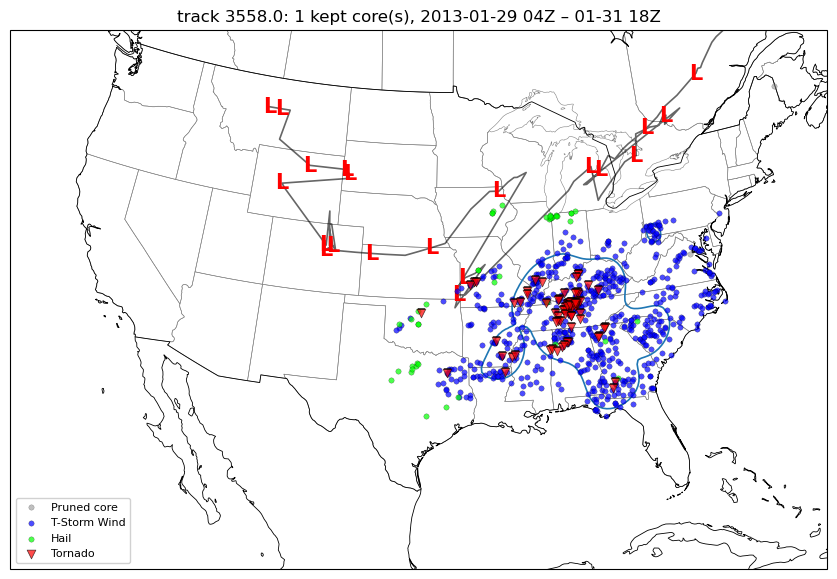

In [72]:
plot_track_cores(track_id=3558.0, 
                 df=df, bandwidth=1, 
                 pdf_thresh=0.005, 
                 tracks_h=tracks_h, 
                 savepath=False
                 )
## 2759.0


In [25]:
etc_summary = pd.read_csv('data/etc_summary_final.csv')

In [27]:
top_cases = etc_summary.sort_values('n_cores_kept', ascending=False).head(50)
top_cases

,track_id,track_start,track_end,time_min_msl,min_msl,n_steps,n_reports,n_tornado,n_hail,n_wind,n_cores_total,n_cores_kept,kept_reports,max_core_reports
2076,5702.0,2023-03-23 19:00:00+00:00,2023-03-31 23:00:00+00:00,2023-03-25 21:00:00+00:00,987.6912,178,376,37,95,244,4,3,368,255
585,1547.0,2003-03-16 13:00:00+00:00,2003-03-22 06:00:00+00:00,2003-03-17 22:00:00+00:00,986.6756,131,451,28,346,77,4,3,429,267
1259,3390.0,2012-03-29 05:00:00+00:00,2012-03-31 23:00:00+00:00,2012-03-30 00:00:00+00:00,1000.3380,56,368,2,328,38,10,3,337,158
1687,4614.0,2018-03-15 02:00:00+00:00,2018-03-24 09:00:00+00:00,2018-03-21 18:00:00+00:00,988.7294,209,360,30,249,81,5,3,335,160
1607,4385.0,2017-02-22 21:00:00+00:00,2017-02-28 07:00:00+00:00,2017-02-27 15:00:00+00:00,959.5638,131,297,6,138,153,4,2,287,207
248,659.0,1999-01-16 17:00:00+00:00,1999-01-27 23:00:00+00:00,1999-01-26 10:00:00+00:00,972.3819,263,338,27,139,172,2,2,338,294
346,885.0,2000-02-16 14:00:00+00:00,2000-02-19 11:00:00+00:00,2000-02-17 21:00:00+00:00,995.8006,67,156,10,98,48,4,2,136,94
1910,5282.0,2021-03-11 04:00:00+00:00,2021-03-19 01:00:00+00:00,2021-03-17 01:00:00+00:00,994.9212,176,455,93,194,168,11,2,331,272
58,69.0,1996-03-21 08:00:00+00:00,1996-03-29 14:00:00+00:00,1996-03-25 20:00:00+00:00,986.0400,190,376,5,199,172,4,2,339,303
822,2300.0,2006-12-01 00:00:00+00:00,2006-12-03 01:00:00+00:00,2006-12-01 21:00:00+00:00,990.2706,50,185,9,7,169,3,2,183,139


In [32]:
day = pd.Timestamp('2020-02-05').date()
df.loc[df['time_hour'].dt.date == day, 'track_id'].unique()

array([5037, 5036])

#### investigating specific core_ids

In [40]:
test = df[df['track_id'] == 290].sort_values('time_hour')
print(test[['time_hour','report_lon','report_lat','core_id','core_kept']].to_string())

                     time_hour  report_lon  report_lat  core_id core_kept
4449 1997-03-28 00:00:00+00:00      -96.88       35.70  290_0g0      True
4448 1997-03-28 00:00:00+00:00      -98.40       36.72  290_0g0      True
4680 1997-03-28 00:00:00+00:00      -99.75       35.55  290_0g0      True
4635 1997-03-28 00:00:00+00:00      -97.87       36.10  290_0g0      True
4447 1997-03-28 00:00:00+00:00      -97.68       36.88  290_0g0      True
4392 1997-03-28 00:00:00+00:00      -97.67       37.03  290_0g0      True
4446 1997-03-28 00:00:00+00:00      -97.80       36.83  290_0g0      True
4445 1997-03-28 00:00:00+00:00      -97.27       35.50  290_0g0      True
4444 1997-03-28 00:00:00+00:00      -97.47       35.45  290_0g0      True
4502 1997-03-28 01:00:00+00:00      -96.22       35.95  290_0g0      True
4503 1997-03-28 01:00:00+00:00      -96.22       35.95  290_0g0      True
4501 1997-03-28 01:00:00+00:00      -96.38       35.83  290_0g0      True
4429 1997-03-28 01:00:00+00:00      -9

In [ ]:
gc = df[df['core_id'] == '290_0g1'].sort_values('time_hour')
print(gc[['time_hour', 'report_lon', 'report_lat', 'core_kept']].to_string())

                     time_hour  report_lon  report_lat core_kept
4382 1997-03-28 18:00:00+00:00      -85.23       30.78      True
4341 1997-03-28 21:00:00+00:00      -89.60       38.18      True
3337 1997-03-28 21:00:00+00:00      -89.73       39.95      True
3738 1997-03-28 21:00:00+00:00      -90.10       38.08      True
3739 1997-03-28 21:00:00+00:00      -89.87       38.73      True
3736 1997-03-28 21:00:00+00:00      -90.62       38.80      True
3737 1997-03-28 21:00:00+00:00      -90.17       38.57      True
3708 1997-03-28 21:00:00+00:00      -89.70       38.12      True
3709 1997-03-28 21:00:00+00:00      -89.67       38.12      True
3710 1997-03-28 21:00:00+00:00      -89.55       38.43      True
4340 1997-03-28 21:00:00+00:00      -89.60       38.18      True
3339 1997-03-28 22:00:00+00:00      -89.37       40.15      True
4339 1997-03-28 22:00:00+00:00      -89.22       38.22      True
4338 1997-03-28 22:00:00+00:00      -89.78       39.02      True
3289 1997-03-28 22:00:00+

In [44]:
from itertools import combinations

test = df[df['track_id'] == 290].dropna(subset=['core_id'])
for cid, g in test.groupby('core_id'):
    lon_span = g['report_lon'].max() - g['report_lon'].min()
    lat_span = g['report_lat'].max() - g['report_lat'].min()
    # crude diagonal extent in degrees
    diag = (lon_span**2 + lat_span**2)**0.5
    print(f"{cid}: n={len(g):4d}  lon_span={lon_span:5.1f}  "
          f"lat_span={lat_span:5.1f}  diag={diag:5.1f}deg  "
          f"kept={g['core_kept'].iloc[0]}")

290_0g0: n=  69  lon_span= 12.0  lat_span=  3.5  diag= 12.6deg  kept=True
290_0g1: n= 266  lon_span=  9.9  lat_span= 10.0  diag= 14.0deg  kept=True
290_0g2: n=  42  lon_span= 15.3  lat_span= 12.1  diag= 19.5deg  kept=False
290_0g3: n=   2  lon_span=  3.5  lat_span=  1.2  diag=  3.6deg  kept=False


In [43]:
for cid, g in test.groupby('core_id'):
    # for each hour, how wide is the core spatially?
    per_hr = g.groupby('time_hour').agg(
        lon_span=('report_lon', lambda s: s.max()-s.min()),
        lat_span=('report_lat', lambda s: s.max()-s.min()))
    max_inst_lon = per_hr['lon_span'].max()
    print(f"{cid}: max single-hour lon span = {max_inst_lon:.1f}deg "
          f"kept={g['core_kept'].iloc[0]}")

290_0g0: max single-hour lon span = 7.2deg kept=True
290_0g1: max single-hour lon span = 6.6deg kept=True
290_0g2: max single-hour lon span = 14.9deg kept=False
290_0g3: max single-hour lon span = 0.0deg kept=False


In [45]:
# Max single-hour lon (and lat) span for every KEPT core, season-wide
kept = df[df['core_kept'] == True].dropna(subset=['core_id'])

def max_inst_span(g):
    per_hr = g.groupby('time_hour').agg(
        lon=('report_lon', lambda s: s.max()-s.min()),
        lat=('report_lat', lambda s: s.max()-s.min()))
    return pd.Series({'max_lon_span': per_hr['lon'].max(),
                      'max_lat_span': per_hr['lat'].max(),
                      'n_reports': len(g)})

spans = kept.groupby('core_id').apply(max_inst_span)
print(spans.sort_values('max_lon_span', ascending=False).head(20))
print(f"\nkept cores with max single-hour lon span > 9deg: "
      f"{(spans['max_lon_span'] > 9).sum()} / {len(spans)}")

          max_lon_span  max_lat_span  n_reports
core_id                                        
3387_3        19.75000       1.81000      158.0
3598_0        18.13000       3.90000      179.0
5295_0g0      17.42930       7.89160       77.0
54_1g2        16.84000       6.94000       84.0
5900_1g2      16.65000       8.14990      332.0
5075_1g2      16.51000      10.53950      350.0
4002_0g1      15.57000       5.06110      130.0
895_1g1       15.35000       5.20000      164.0
482_2g1       15.01000       5.75000      112.0
1334_0g1      14.95000       4.21667      211.0
4408_0g1      14.08000       9.82000       92.0
2533_0g1      13.76510       8.51000      198.0
6113_1        13.68000       6.77390      168.0
4387_1g2      13.64830       7.82000      987.0
6117_4g1      13.50000      11.91990      821.0
4804_2g4      12.96280       4.18000       94.0
6102_2        12.94000      12.49000     1061.0
896_1g0       12.76667       9.95000       62.0
60_1g1        12.72000       4.32000    

/tmp/ipykernel_845109/2505952659.py:12: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  spans = kept.groupby('core_id').apply(max_inst_span)


In [57]:
random = df[df['core_id'] == '6102_2']
random['track_id']

79457    6102
79458    6102
79459    6102
79460    6102
79462    6102
         ... 
83935    6102
83936    6102
83937    6102
83962    6102
83963    6102
Name: track_id, Length: 1061, dtype: int64

#### Does core_id 290_0g2 fail due to the report threshold or the density threshold?

In [59]:
r = core_summary.set_index('core_id').loc['290_0g2']
pass_reports = r['n_reports']    >= r['thr_reports']
pass_density = r['density_ratio'] >= r['thr_density_ratio']
print(f"reports: {r['n_reports']:.0f} vs thr {r['thr_reports']:.1f}  -> {'PASS' if pass_reports else 'FAIL'}")
print(f"density: {r['density_ratio']:.4f} vs thr {r['thr_density_ratio']:.4f}  -> {'PASS' if pass_density else 'FAIL'}")


reports: 42 vs thr 35.6  -> PASS
density: 0.0279 vs thr 0.0319  -> FAIL


It fails because of the density ratio! This means it is working exactly the way it is supposed to work!

#### What's the distribution of cores kept per cyclone? 

In [43]:
kept = core_summary[core_summary['kept']]
cores_per_cyclone = kept.groupby('track_id')['core_id'].nunique()

In [44]:
dist = cores_per_cyclone.value_counts().sort_index()
print(dist)

core_id
1    212
2     54
3      4
Name: count, dtype: int64


## Finalize outputs and save to CSVs:

In [27]:
etc_summary = pd.read_csv('data/etc_summary_final.csv')
core_summary = pd.read_csv('data/kde_core_summary.csv')
reports_tagged = pd.read_csv('data/reports_tagged_final.csv', low_memory=False)

In [41]:
## Core-level enrichment
def enrich_core_summary(core_summary: pd.DataFrame,
                        df: pd.DataFrame) -> pd.DataFrame:
    """
    Add per-core fields computed from the member reports in df:
        centroid_lat, centroid_lon  - mean report position
        onset_time                  - first report time (= t_start, explicit)
        peak_time                   - hour with the most reports
        peak_n_reports              - report count in that peak hour

    Joined back to core_summary on core_id. Assumes df has columns
    ['core_id','time_hour','report_lon','report_lat'].
    """
    g = df.dropna(subset=['core_id'])

    # centroid (unweighted mean of report positions)
    centroid = (g.groupby('core_id')
                  .agg(centroid_lat=('report_lat', 'mean'),
                       centroid_lon=('report_lon', 'mean'),
                       onset_time=('time_hour', 'min')))

    # peak hour: the time_hour with the most reports in each core
    hourly = (g.groupby(['core_id', 'time_hour'])
                .size()
                .rename('n_in_hour')
                .reset_index())
    # for ties, idxmax takes the first (earliest) peak hour
    peak_idx = hourly.groupby('core_id')['n_in_hour'].idxmax()
    peak = (hourly.loc[peak_idx]
                  .set_index('core_id')
                  .rename(columns={'time_hour': 'peak_time',
                                   'n_in_hour': 'peak_n_reports'}))

    enrich = centroid.join(peak)

    out = core_summary.merge(enrich, on='core_id', how='left')
    return out

In [42]:
core_summary = enrich_core_summary(core_summary, df)

In [44]:
core_summary.columns

Index(['track_id', 'core_id', 'n_reports', 'n_tornado', 'n_hail', 'n_wind',
       't_start', 't_end', 'lat_min', 'lax_max', 'lon_min', 'lon_max',
       'duration_h', 'grid_points', 'density_ratio', 'season_year',
       'thr_reports', 'thr_density_ratio', 'kept', 'centroid_lat',
       'centroid_lon', 'onset_time', 'peak_time', 'peak_n_reports'],
      dtype='object')

In [24]:
core_summary.to_csv('data/kde_core_summary.csv', index=False)

In [46]:
## ETC-level enrichment
def enrich_etc_summary(etc_summary: pd.DataFrame,
                       core_summary: pd.DataFrame,
                       track_col: str = 'track_id') -> pd.DataFrame:
    """
    Append per-ETC core information:
        n_cores_total      - all cores on the track
        n_cores_kept       - cores surviving the detrended filter
        kept_reports       - total reports across that track's KEPT cores
        max_core_reports   - largest kept core's report count (0 if none kept)
    Tracks with no kept cores get 0 (not NaN); the track stays in the table.
    """
    cs = core_summary
    kept = cs[cs['kept']] if 'kept' in cs.columns else cs[cs['core_kept']]

    total = (cs.groupby(track_col)['core_id'].nunique()
               .rename('n_cores_total'))
    kept_n = (kept.groupby(track_col)['core_id'].nunique()
                .rename('n_cores_kept'))
    kept_reports = (kept.groupby(track_col)['n_reports'].sum()
                      .rename('kept_reports'))
    max_core = (kept.groupby(track_col)['n_reports'].max()
                  .rename('max_core_reports'))

    out = etc_summary.copy()
    for s in (total, kept_n, kept_reports, max_core):
        out = out.merge(s, left_on=track_col, right_index=True, how='left')

    fill0 = ['n_cores_total', 'n_cores_kept', 'kept_reports', 'max_core_reports']
    out[fill0] = out[fill0].fillna(0).astype(int)
    return out

In [ ]:
etc_summary = pd.read_csv('data/etc_summary_final.csv')
etc_summary = enrich_etc_summary(etc_summary, core_summary, track_col='track_id')

In [25]:
etc_summary.to_csv('data/etc_summary_final.csv', index=False)

In [39]:
## report level enrichment
core_cols = ['core_id','core_kept']

reports_full = reports_tagged.merge(
    df[['EVENT_ID'] + core_cols],
    on='EVENT_ID',
    how='left',    ## keep every original report
)

# sanity: row count must match the original
assert len(reports_full) == len(reports_tagged), \
    f"{len(reports_full)} vs {len(reports_tagged)} — merge duplicated or dropped rows"

print(f"{len(reports_full)} total reports")
print(f"  {reports_full['track_id'].notna().sum()} associated to an ETC")
print(f"  {reports_full['core_id'].notna().sum()} assigned to a core")
print(f"  {reports_full['core_id'].isna().sum()} with no core (unassociated + proxfail + assigned to no core)")

83969 total reports
  67189 associated to an ETC
  66568 assigned to a core
  17401 with no core (unassociated + proxfail + assigned to no core)


In [26]:
reports_tagged.to_csv('data/reports_tagged_final.csv', index=False)

## Sensitivity experiments to find the ideal gap_hours and window length

In [20]:
## Sensitivity test for window and gap_hours

def run_grid(df,
             windows=(9,12,15,18,24),
             gaps=(3,6,9,12),
             feb_track_id=None,
             bandwidth=1.0,
             pdf_thresh=0.001,
             min_reports=5):
    
    rows = []

    for win in windows:
        # one engine pass per window value
        core_local = pd.Series(-1, index=df.index, dtype=int)
        for tid, g in df.groupby('track_id'):
            core_local.loc[g.index] = kde_cluster_track(
                g, bandwidth=bandwidth, pdf_thresh=pdf_thresh,
                win_hours=win, min_reports=min_reports,
            )
        base = df.copy()
        base['core_local'] = core_local
        base['core_id'] = np.where(
            base['core_local'] >= 0,
            base['track_id'].astype(str) + '_' + base['core_local'].astype(str),
            np.nan,
        )

        ## apply each gap value to this window's cores
        for gap in gaps:
            cg = split_cores_on_gap(base, gap_hours=gap)
            assigned = cg.notna()

            n_cores = cg.dropna().nunique()
            n_assigned = int(assigned.sum())
            n_total = len(base)

            feb_cores = np.nan 
            if feb_track_id is not None:
                feb_mask = base['track_id'] == feb_track_id
                feb_cores = cg[feb_mask].dropna().nunique()

            rows.append({
                'win_hours': win,
                'gap_hours': gap,
                'n_cores_season': n_cores,
                'n_assigned': n_assigned,
                'assign_frac': round(n_assigned / n_total, 4),
                'feb_n_cores': feb_cores,
            })

    out = pd.DataFrame(rows).sort_values(['win_hours','gap_hours'])
    return out.reset_index(drop=True)

In [40]:
grid = run_grid(df, feb_track_id=8316)
print(grid.to_string(index=False))

 win_hours  gap_hours  n_cores_season  n_assigned  assign_frac  feb_n_cores
         9          3              36        2363       0.9752            5
         9          6              27        2363       0.9752            4
         9          9              26        2363       0.9752            4
         9         12              26        2363       0.9752            4
        12          3              38        2372       0.9790            5
        12          6              29        2372       0.9790            4
        12          9              27        2372       0.9790            4
        12         12              25        2372       0.9790            3
        15          3              39        2373       0.9794            6
        15          6              30        2373       0.9794            5
        15          9              28        2373       0.9794            5
        15         12              25        2373       0.9794            3
        18  

In [43]:
feb_track = df[df['track_id'] == 8316]

In [44]:
feb_track['core_id'].value_counts()

core_id
8316_1g2    350
8316_1g1     65
8316_2       18
8316_1g0     17
8316_0       13
Name: count, dtype: int64

In [41]:
def inspect_core_seams(track_id, df):
    """
    For one track, show each core's time span and the quiet gap BETWEEN
    consecutive cores. Long between-core gaps = defensible seams;
    very short ones = candidates for over-splitting.
    """
    g = df[df['track_id'] == track_id].dropna(subset=['core_id'])
    summary = (g.groupby('core_id')['time_hour']
                 .agg(['min', 'max', 'size'])
                 .sort_values('min'))
    summary['duration_h'] = (
        (summary['max'] - summary['min']).dt.total_seconds() / 3600
    )

    print(f"Track {track_id}: {len(summary)} cores\n")
    prev_end = None
    for cid, row in summary.iterrows():
        if prev_end is not None:
            seam = (row['min'] - prev_end).total_seconds() / 3600
            print(f"   --- quiet gap between cores: {seam:.1f} h ---")
        print(f"  {cid}: {row['min']:%m-%d %H}Z -> {row['max']:%m-%d %H}Z  "
              f"({row['duration_h']:.0f}h, {int(row['size'])} reports)")
        prev_end = row['max']

In [42]:
inspect_core_seams(8316, df)

Track 8316: 5 cores

  8316_0: 03-25 18Z -> 03-25 22Z  (4h, 13 reports)
   --- quiet gap between cores: 30.0 h ---
  8316_1g0: 03-27 04Z -> 03-27 07Z  (3h, 17 reports)
   --- quiet gap between cores: 10.0 h ---
  8316_1g1: 03-27 17Z -> 03-28 04Z  (11h, 65 reports)
   --- quiet gap between cores: 4.0 h ---
  8316_1g2: 03-28 08Z -> 03-29 10Z  (26h, 350 reports)
   --- quiet gap between cores: 7.0 h ---
  8316_2: 03-29 17Z -> 03-30 01Z  (8h, 18 reports)


In [56]:
core_summary['duration_h'].max()

np.float64(53.0)

In [60]:
core_summary[core_summary['duration_h'] == 53.0]

,track_id,core_id,n_reports,n_tornado,n_hail,n_wind,t_start,t_end,lat_min,lax_max,lon_min,lon_max,duration_h,grid_points,density_ratio,season_year,thr_reports,thr_density_ratio,kept
837,3558,3558_0,780,75,44,661,2013-01-29 04:00:00+00:00,2013-01-31 09:00:00+00:00,29.7364,42.43,-99.4,-74.7063,53.0,3427,0.227604,2013,43.357865,0.036407,True
